# Laplacian Eigenmaps for Nonlinear Dimensionality Reduction

## Overview

High-dimensional data often lies on or near a low-dimensional **manifold** embedded in the ambient space. Linear methods like PCA find the best linear subspace, but fail for curved manifolds. **Laplacian Eigenmaps** (Belkin & Niyogi, 2003) is a spectral method that exploits the **local geometry** of the data to find a faithful low-dimensional embedding.

The key idea: nearby points in the original space should remain nearby in the embedding. This is formalized using a **graph Laplacian** built from a $k$-nearest-neighbor graph.

## Graph Construction

Given $n$ data points $\{x_i\}_{i=1}^n$:
1. Build a $k$-NN graph (connect each point to its $k$ nearest neighbors)
2. Define edge weights using a Gaussian kernel:
   $$W_{ij} = \exp\!\left(-\frac{\|x_i - x_j\|^2}{\sigma^2}\right) \quad \text{if } i, j \text{ are neighbors, else } 0$$

## Graph Laplacian

The **unnormalized graph Laplacian**: $L = D - W$, where $D = \mathrm{diag}(d_i)$, $d_i = \sum_j W_{ij}$.

Two normalized variants:
- **Symmetric**: $\mathcal{L} = D^{-1/2} L D^{-1/2} = I - D^{-1/2} W D^{-1/2}$
- **Random-walk**: $\tilde{L} = D^{-1} L = I - D^{-1} W$

## The Embedding

The embedding minimizes the **locality-preserving objective**:
$$
\min_Y \sum_{i,j} W_{ij} \|y_i - y_j\|^2 = \min_Y \mathrm{tr}(Y^\top L Y)
$$
subject to $Y^\top D Y = I$ (normalization). This is a **generalized eigenvalue problem**:
$$
L \mathbf{u} = \lambda D \mathbf{u}
$$
The smallest eigenvalue is $\lambda_1 = 0$ with eigenvector $\mathbf{1}$ (constant, uninformative). The **embedding coordinates** are the eigenvectors $u_2, u_3, \ldots$ corresponding to the next-smallest eigenvalues.

## The Fiedler Vector

The eigenvector $u_2$ (Fiedler vector) corresponds to the smallest nonzero eigenvalue $\lambda_2$ (the **algebraic connectivity** of the graph). It is the smoothest non-constant function on the graph and serves as a natural parameterization of the manifold along its principal direction.

## What This Notebook Demonstrates

1. Two-moons dataset: Laplacian Eigenmaps correctly separates the two crescents
2. Swiss roll (3D → 2D): unrolls the spiral manifold
3. Helix (3D → 1D): parameterizes the helix by arc length
4. Comparison with PCA on all datasets
5. Effect of bandwidth $\sigma$ and neighborhood $k$

### Setup

We implement Laplacian Eigenmaps from scratch using numpy/scipy, without relying on sklearn's manifold module (which would hide the construction). We use `scipy.sparse.linalg.eigsh` for efficient sparse eigendecomposition of large graphs.

In [1]:
import numpy as np
import matplotlib
if 'get_ipython' not in globals():
    matplotlib.use('Agg')
import matplotlib.pyplot as plt
from scipy.spatial import cKDTree
from scipy.sparse import csr_matrix, diags
from scipy.sparse.linalg import eigsh

plt.rcParams.update({'font.size': 12, 'figure.dpi': 100})

print("Libraries imported.")

Libraries imported.


### Building the Graph Laplacian

We construct the $k$-NN graph using a KD-tree for efficiency ($O(n \log n)$ queries). For each point we find its $k$ nearest neighbors, then assign Gaussian edge weights $W_{ij} = e^{-\|x_i - x_j\|^2/\sigma^2}$. The graph is made symmetric by taking $W \leftarrow \max(W, W^\top)$.

The generalized eigenvalue problem $Lu = \lambda Du$ is equivalent to $D^{-1/2}LD^{-1/2} v = \lambda v$ (with $v = D^{1/2}u$), which is a standard symmetric eigenvalue problem solvable by `eigsh`.

In [2]:
def build_laplacian(X, k=10, sigma=None):
    """
    Build symmetric normalized graph Laplacian L_sym = D^{-1/2} L D^{-1/2}.
    Also return the degree matrix D for the generalized eigenproblem.

    X: (n, d) data matrix
    k: number of nearest neighbors
    sigma: Gaussian bandwidth (if None, use median of pairwise distances)
    """
    n = X.shape[0]
    tree = cKDTree(X)
    dists, idxs = tree.query(X, k=k + 1)  # k+1 because query returns self

    if sigma is None:
        sigma = np.median(dists[:, 1:])  # median of nearest-neighbor distances

    # Build sparse weight matrix
    rows, cols, vals = [], [], []
    for i in range(n):
        for j_idx in range(1, k + 1):  # skip self
            j = idxs[i, j_idx]
            d = dists[i, j_idx]
            w = np.exp(-d**2 / sigma**2)
            rows.append(i); cols.append(j); vals.append(w)
            rows.append(j); cols.append(i); vals.append(w)  # symmetrize

    W = csr_matrix((vals, (rows, cols)), shape=(n, n))
    # Symmetrize (take max)
    W = (W + W.T) / 2

    # Degree vector
    d_vec = np.array(W.sum(axis=1)).ravel()
    D_inv_sqrt = diags(1.0 / np.sqrt(d_vec + 1e-12))
    D_mat = diags(d_vec)

    # Unnormalized Laplacian
    L = D_mat - W
    # Normalized symmetric Laplacian
    L_sym = D_inv_sqrt @ L @ D_inv_sqrt

    return L_sym, D_mat, d_vec, sigma

## Extract nontrivial spectral coordinates

After diagonalizing $L_{\mathrm{sym}}$, we discard the constant mode and map normalized eigenvectors back through $D^{-1/2}$.

In [3]:
def laplacian_eigenmaps(X, n_components=2, k=10, sigma=None):
    """
    Compute Laplacian Eigenmap embedding of X into R^{n_components}.
    Returns (Y, eigenvalues) where Y has shape (n, n_components).
    """
    L_sym, D, d_vec, sig = build_laplacian(X, k=k, sigma=sigma)
    # Compute smallest n_components+1 eigenvalues/vectors
    # (skip the trivial lambda=0 eigenvector)
    evals, evecs = eigsh(L_sym, k=n_components + 1, which='SM', tol=1e-6)
    # Sort by eigenvalue
    order = np.argsort(evals)
    evals = evals[order]
    evecs = evecs[:, order]

    # Convert from normalized to original: u = D^{-1/2} v
    D_inv_sqrt = 1.0 / np.sqrt(d_vec + 1e-12)
    evecs_orig = evecs * D_inv_sqrt[:, None]

    # Skip first eigenvector (constant, lambda ~ 0)
    Y = evecs_orig[:, 1:n_components + 1]
    return Y, evals, sig


print("Laplacian Eigenmaps implementation ready.")

Laplacian Eigenmaps implementation ready.


### Generating the Datasets

We create three benchmark manifold datasets:

1. **Two-moons**: two interleaved crescent-shaped clusters in 2D. PCA cannot separate them linearly.
2. **Swiss roll**: a 2D manifold coiled into 3D like a cinnamon roll. The true coordinates are angle $\phi$ and height $z$.
3. **Helix**: a 1D manifold coiled in 3D, parametrized by arc length $s$.

In [4]:
rng = np.random.default_rng(42)

def make_two_moons(n=500, noise=0.08):
    theta1 = np.linspace(0, np.pi, n // 2)
    theta2 = np.linspace(np.pi, 2 * np.pi, n // 2)
    X1 = np.stack([np.cos(theta1), np.sin(theta1)], axis=1)
    X2 = np.stack([1 - np.cos(theta2), -np.sin(theta2) + 0.5], axis=1)
    X = np.vstack([X1, X2])
    X += rng.standard_normal(X.shape) * noise
    labels = np.hstack([np.zeros(n // 2), np.ones(n // 2)])
    return X, labels

def make_swiss_roll(n=800, noise=0.2):
    phi = rng.uniform(1.5 * np.pi, 4.5 * np.pi, n)
    z = rng.uniform(0, 10, n)
    x = phi * np.cos(phi)
    y = phi * np.sin(phi)
    X = np.stack([x, y, z], axis=1)
    X += rng.standard_normal(X.shape) * noise
    return X, phi  # phi is the true manifold coordinate

def make_helix(n=400, noise=0.05):
    s = np.linspace(0, 4 * np.pi, n)  # arc-length parameter
    x = np.cos(s)
    y = np.sin(s)
    z = s / (2 * np.pi)
    X = np.stack([x, y, z], axis=1)
    X += rng.standard_normal(X.shape) * noise
    return X, s

X_moons, y_moons = make_two_moons(500)
X_swiss, phi_swiss = make_swiss_roll(800)
X_helix, s_helix = make_helix(400)

print(f"Two-moons: {X_moons.shape}")
print(f"Swiss roll: {X_swiss.shape}")
print(f"Helix: {X_helix.shape}")

Two-moons: (500, 2)
Swiss roll: (800, 3)
Helix: (400, 3)


### Linear PCA as Baseline

Principal Component Analysis (PCA) finds the directions of maximum variance by eigendecomposing the covariance matrix $C = \frac{1}{n} X^\top X$ (after centering). The top-$d$ eigenvectors give the best linear projection minimizing reconstruction error.

For curved manifolds, PCA misses the intrinsic geometry: it projects all three datasets into flat subspaces that fail to separate or unroll the manifold structure.

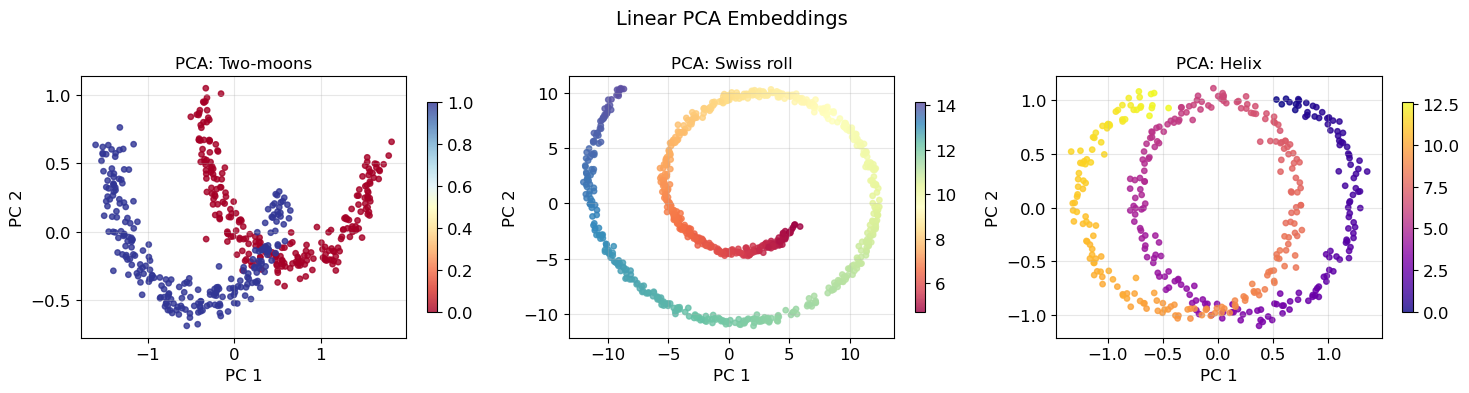

<Figure size 640x480 with 0 Axes>

In [5]:
def pca(X, n_components=2):
    """Simple PCA: center, covariance, top eigenvectors."""
    Xc = X - X.mean(axis=0)
    C = (Xc.T @ Xc) / len(X)
    evals, evecs = np.linalg.eigh(C)
    # Sort descending
    order = np.argsort(evals)[::-1]
    evecs = evecs[:, order[:n_components]]
    return Xc @ evecs


Y_moons_pca = pca(X_moons)
Y_swiss_pca = pca(X_swiss)
Y_helix_pca = pca(X_helix)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
scatter_data = [
    (Y_moons_pca, y_moons, 'Two-moons', 'RdYlBu'),
    (Y_swiss_pca, phi_swiss, 'Swiss roll', 'Spectral'),
    (Y_helix_pca, s_helix, 'Helix', 'plasma'),
]
for ax, (Y, c, title, cmap) in zip(axes, scatter_data):
    sc = ax.scatter(Y[:, 0], Y[:, 1], c=c, cmap=cmap, s=15, alpha=0.8)
    ax.set_title(f'PCA: {title}', fontsize=12)
    ax.set_xlabel('PC 1')
    ax.set_ylabel('PC 2')
    plt.colorbar(sc, ax=ax, shrink=0.8)
    ax.grid(True, alpha=0.3)

plt.suptitle('Linear PCA Embeddings', fontsize=14)
plt.tight_layout()
plt.show()
plt.savefig("pca_results.png", dpi=80, bbox_inches='tight')
plt.show()

### Laplacian Eigenmaps Embeddings

We now apply Laplacian Eigenmaps to the same three datasets. The embedding coordinates are the Fiedler vector $u_2$ and $u_3$ (second and third non-trivial eigenvectors of $L$).

For two-moons, the two clusters should appear clearly separated along $u_2$ alone. For the Swiss roll, the two embedding coordinates should cleanly unfold the manifold. For the helix, $u_2$ should be monotone in arc length $s$.

Two-moons: sigma=0.082, lambda_2=0.0007
Swiss roll: sigma=1.698, lambda_2=0.0021
Helix: sigma=0.126, lambda_2=0.0006


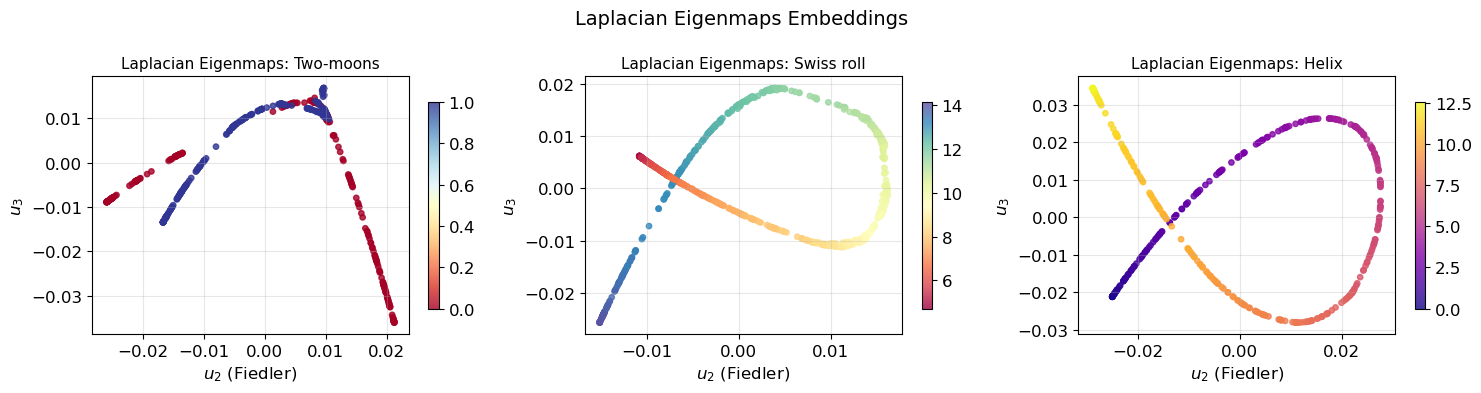

<Figure size 640x480 with 0 Axes>

In [6]:
Y_moons_le, evals_m, sig_m = laplacian_eigenmaps(X_moons, n_components=2, k=12)
Y_swiss_le, evals_s, sig_s = laplacian_eigenmaps(X_swiss, n_components=2, k=15)
Y_helix_le, evals_h, sig_h = laplacian_eigenmaps(X_helix, n_components=2, k=8)

print(f"Two-moons: sigma={sig_m:.3f}, lambda_2={evals_m[1]:.4f}")
print(f"Swiss roll: sigma={sig_s:.3f}, lambda_2={evals_s[1]:.4f}")
print(f"Helix: sigma={sig_h:.3f}, lambda_2={evals_h[1]:.4f}")

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
le_data = [
    (Y_moons_le, y_moons, 'Two-moons', 'RdYlBu'),
    (Y_swiss_le, phi_swiss, 'Swiss roll', 'Spectral'),
    (Y_helix_le, s_helix, 'Helix', 'plasma'),
]
for ax, (Y, c, title, cmap) in zip(axes, le_data):
    sc = ax.scatter(Y[:, 0], Y[:, 1], c=c, cmap=cmap, s=15, alpha=0.8)
    ax.set_title(f'Laplacian Eigenmaps: {title}', fontsize=11)
    ax.set_xlabel('$u_2$ (Fiedler)')
    ax.set_ylabel('$u_3$')
    plt.colorbar(sc, ax=ax, shrink=0.8)
    ax.grid(True, alpha=0.3)

plt.suptitle('Laplacian Eigenmaps Embeddings', fontsize=14)
plt.tight_layout()
plt.show()
plt.savefig("le_results.png", dpi=80, bbox_inches='tight')
plt.show()

### The Fiedler Vector

The **Fiedler vector** $u_2$ is the eigenvector of $L$ corresponding to $\lambda_2$, the algebraic connectivity. It is the smoothest non-constant function on the graph: it varies slowly between connected neighbors.

For the two-moons dataset, $u_2$ is essentially an indicator function of the two clusters. For the helix, $u_2$ is nearly monotone in the arc-length parameter $s$, demonstrating that the Fiedler vector recovers the intrinsic parameterization.

We visualize $u_2$ mapped back onto the original data space.

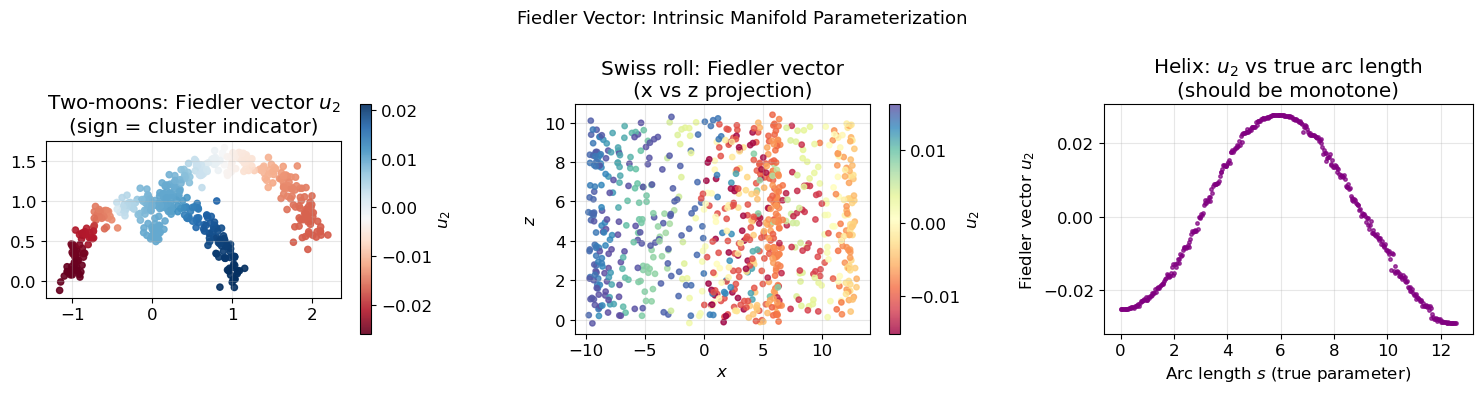

<Figure size 640x480 with 0 Axes>

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Two-moons: color original 2D points by Fiedler vector
ax = axes[0]
sc = ax.scatter(X_moons[:, 0], X_moons[:, 1], c=Y_moons_le[:, 0],
                cmap='RdBu', s=20, alpha=0.9)
plt.colorbar(sc, ax=ax, label='$u_2$')
ax.set_title('Two-moons: Fiedler vector $u_2$\n(sign = cluster indicator)')
ax.set_aspect('equal')
ax.grid(True, alpha=0.3)

# Swiss roll: 3D plot colored by Fiedler vector
ax = axes[1]
sc = ax.scatter(X_swiss[:, 0], X_swiss[:, 2], c=Y_swiss_le[:, 0],
                cmap='Spectral', s=15, alpha=0.8)
plt.colorbar(sc, ax=ax, label='$u_2$')
ax.set_title('Swiss roll: Fiedler vector\n(x vs z projection)')
ax.set_xlabel('$x$'); ax.set_ylabel('$z$')
ax.grid(True, alpha=0.3)

# Helix: Fiedler vector vs arc length
ax = axes[2]
ax.plot(s_helix, Y_helix_le[:, 0], '.', ms=5, alpha=0.7, color='purple')
ax.set_xlabel('Arc length $s$ (true parameter)')
ax.set_ylabel('Fiedler vector $u_2$')
ax.set_title('Helix: $u_2$ vs true arc length\n(should be monotone)')
ax.grid(True, alpha=0.3)

plt.suptitle('Fiedler Vector: Intrinsic Manifold Parameterization', fontsize=13)
plt.tight_layout()
plt.show()
plt.savefig("fiedler_analysis.png", dpi=80, bbox_inches='tight')
plt.show()

### Effect of Bandwidth $\sigma$ and Neighborhood $k$

The quality of the embedding depends critically on two hyperparameters:

- **Bandwidth $\sigma$**: controls how rapidly edge weights decay with distance. Too small: graph becomes disconnected; too large: all edges have similar weight and local geometry is lost.
- **Neighborhood size $k$**: larger $k$ gives a more connected graph but may mix different parts of the manifold.

We sweep $\sigma$ and $k$ for the two-moons dataset to illustrate these effects.

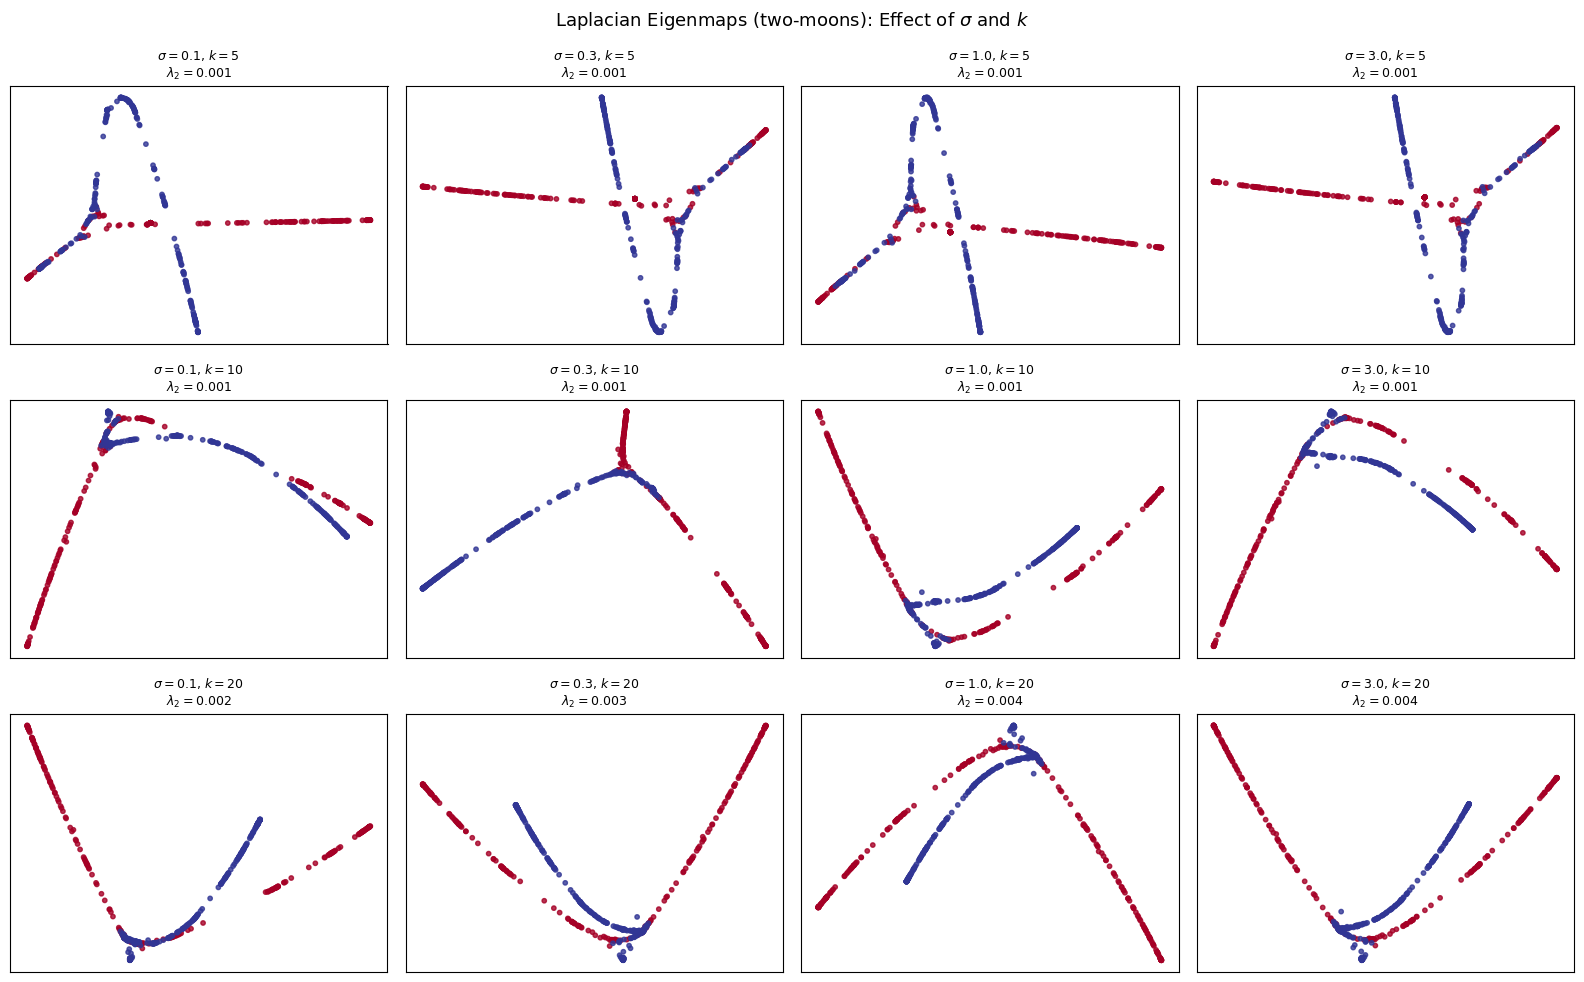

<Figure size 640x480 with 0 Axes>

In [8]:
sigma_vals = [0.1, 0.3, 1.0, 3.0]
k_vals = [5, 10, 20]

fig, axes = plt.subplots(len(k_vals), len(sigma_vals),
                          figsize=(16, 10))

for row, k in enumerate(k_vals):
    for col, sigma in enumerate(sigma_vals):
        ax = axes[row, col]
        try:
            Y, evals, _ = laplacian_eigenmaps(X_moons, n_components=2,
                                               k=k, sigma=sigma)
            sc = ax.scatter(Y[:, 0], Y[:, 1], c=y_moons,
                            cmap='RdYlBu', s=10, alpha=0.8)
            ax.set_title(f'$\\sigma={sigma}$, $k={k}$\n$\\lambda_2={evals[1]:.3f}$',
                         fontsize=9)
        except Exception as e:
            ax.text(0.5, 0.5, f'Failed:\n{str(e)[:30]}',
                    ha='center', va='center', transform=ax.transAxes, fontsize=8)
            ax.set_title(f'$\\sigma={sigma}$, $k={k}$', fontsize=9)
        ax.set_xticks([])
        ax.set_yticks([])

plt.suptitle('Laplacian Eigenmaps (two-moons): Effect of $\\sigma$ and $k$',
             fontsize=13)
plt.tight_layout()
plt.show()
plt.savefig("sigma_k_sweep.png", dpi=80, bbox_inches='tight')
plt.show()

### Interactive Embedding Explorer

The widget below lets you interactively choose the dataset, number of neighbors $k$, and bandwidth $\sigma$, then recompute the Laplacian Eigenmap and display the result alongside the PCA baseline.

### Static Snapshot

This cell generates the snippet image: a two-row, three-column comparison of PCA and Laplacian Eigenmaps on all three datasets.

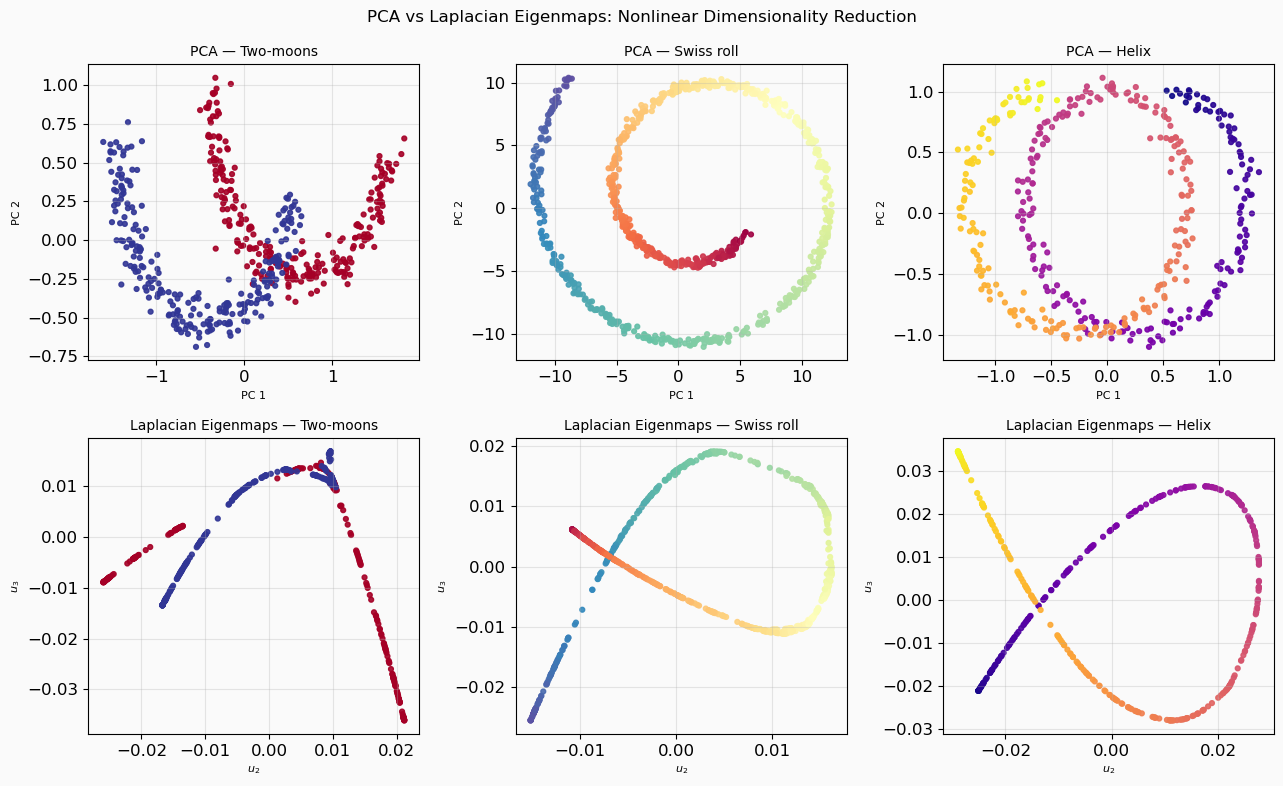

snippet.png saved.


In [9]:
STATIC_SNAPSHOT = True

if STATIC_SNAPSHOT:
    import matplotlib
    if 'get_ipython' not in globals():
        matplotlib.use('Agg')
    import matplotlib.pyplot as plt

    fig_s, axes_s = plt.subplots(2, 3, figsize=(13, 8))
    fig_s.patch.set_facecolor('#fafafa')

    datasets_snap = [
        (X_moons, y_moons, 'Two-moons', 'RdYlBu',
         Y_moons_pca, Y_moons_le),
        (X_swiss, phi_swiss, 'Swiss roll', 'Spectral',
         Y_swiss_pca, Y_swiss_le),
        (X_helix, s_helix, 'Helix', 'plasma',
         Y_helix_pca, Y_helix_le),
    ]

    for col, (X_d, c_d, name, cmap_d, Y_pca, Y_le) in enumerate(datasets_snap):
        # Row 0: PCA
        ax = axes_s[0, col]
        ax.scatter(Y_pca[:, 0], Y_pca[:, 1], c=c_d, cmap=cmap_d, s=12, alpha=0.9)
        ax.set_title(f'PCA — {name}', fontsize=10)
        ax.set_xlabel('PC 1', fontsize=8); ax.set_ylabel('PC 2', fontsize=8)
        ax.grid(True, alpha=0.3)
        ax.set_facecolor('#fafafa')

        # Row 1: Laplacian Eigenmaps
        ax = axes_s[1, col]
        ax.scatter(Y_le[:, 0], Y_le[:, 1], c=c_d, cmap=cmap_d, s=12, alpha=0.9)
        ax.set_title(f'Laplacian Eigenmaps — {name}', fontsize=10)
        ax.set_xlabel('$u_2$', fontsize=8); ax.set_ylabel('$u_3$', fontsize=8)
        ax.grid(True, alpha=0.3)
        ax.set_facecolor('#fafafa')

    plt.suptitle('PCA vs Laplacian Eigenmaps: Nonlinear Dimensionality Reduction',
                 fontsize=12)
    plt.tight_layout()
    plt.show()
    plt.savefig("snippet.png", dpi=100, bbox_inches='tight',
                facecolor=fig_s.get_facecolor())
    plt.close()
    print("snippet.png saved.")

## Takeaways

- **Laplacian Eigenmaps** builds a $k$-NN graph with Gaussian edge weights $W_{ij} = e^{-\|x_i-x_j\|^2/\sigma^2}$, then embeds the data by solving the generalized eigenvalue problem $Lu = \lambda Du$.
- The **Fiedler vector** $u_2$ (second non-trivial eigenvector) captures the primary direction of variation along the manifold; it is the smoothest non-constant function on the graph.
- The embedding **minimizes $\sum_{ij} W_{ij}\|y_i-y_j\|^2$**, ensuring nearby points in the original space remain nearby in the embedding — a locality-preserving objective.
- **PCA fails** on curved manifolds (two-moons, Swiss roll, helix) because it can only find linear subspaces; Laplacian Eigenmaps succeeds by exploiting the local (nonlinear) geometry.
- The **bandwidth $\sigma$** and **neighborhood size $k$** are critical hyperparameters: too small breaks connectivity; too large blurs the local geometry and makes all points indistinguishable.
- Laplacian Eigenmaps is the foundation for many related methods: Diffusion Maps, LLE, UMAP, and spectral clustering.

## Bibliography

- **Belkin, M. & Niyogi, P.** (2003). *Laplacian Eigenmaps for dimensionality reduction and data representation.* Neural Computation, 15(6), 1373–1396.
- **Coifman, R. R. & Lafon, S.** (2006). *Diffusion maps.* Applied and Computational Harmonic Analysis, 21(1), 5–30.
- **von Luxburg, U.** (2007). *A tutorial on spectral clustering.* Statistics and Computing, 17(4), 395–416.
- **Chung, F. R. K.** (1997). *Spectral Graph Theory.* American Mathematical Society.
- **Tenenbaum, J. B., de Silva, V. & Langford, J. C.** (2000). *A global geometric framework for nonlinear dimensionality reduction.* Science, 290(5500), 2319–2323.